In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import time

In [8]:
import numpy as np
import tensorflow as tf
import random

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
import os
import shutil

os.makedirs('/kaggle/working/combined/train/NORMAL', exist_ok=True)
os.makedirs('/kaggle/working/combined/train/PNEUMONIA', exist_ok=True)
os.makedirs('/kaggle/working/combined/test/NORMAL', exist_ok=True)
os.makedirs('/kaggle/working/combined/test/PNEUMONIA', exist_ok=True)

orig_train = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train"
orig_test = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test"

new_base = "/kaggle/input/datasets/safro1/extra-dataset/A Primary Chest X-ray Dataset of Normal and Pneumo/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia/Chest-X-Ray Epic Hospital Chittagong, Bangladesh pneumonia"
new_train = f"{new_base}/Training"
new_test = f"{new_base}/Testing"

def copy_images(src_dir, dst_dir, prefix):
    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, f"{prefix}_{fname}")
        shutil.copy2(src, dst)

copy_images(f"{orig_train}/NORMAL", '/kaggle/working/combined/train/NORMAL', 'orig')
copy_images(f"{orig_train}/PNEUMONIA", '/kaggle/working/combined/train/PNEUMONIA', 'orig')
copy_images(f"{new_train}/normal", '/kaggle/working/combined/train/NORMAL', 'new')
copy_images(f"{new_train}/pneumonia", '/kaggle/working/combined/train/PNEUMONIA', 'new')

copy_images(f"{orig_test}/NORMAL", '/kaggle/working/combined/test/NORMAL', 'orig')
copy_images(f"{orig_test}/PNEUMONIA", '/kaggle/working/combined/test/PNEUMONIA', 'orig')
copy_images(f"{new_test}/normal", '/kaggle/working/combined/test/NORMAL', 'new')
copy_images(f"{new_test}/pneumonia", '/kaggle/working/combined/test/PNEUMONIA', 'new')

print("Combined train NORMAL:", len(os.listdir('/kaggle/working/combined/train/NORMAL')))
print("Combined train PNEUMONIA:", len(os.listdir('/kaggle/working/combined/train/PNEUMONIA')))
print("Combined test NORMAL:", len(os.listdir('/kaggle/working/combined/test/NORMAL')))
print("Combined test PNEUMONIA:", len(os.listdir('/kaggle/working/combined/test/PNEUMONIA')))

Combined train NORMAL: 2405
Combined train PNEUMONIA: 4926
Combined test NORMAL: 491
Combined test PNEUMONIA: 646


In [10]:
import os
import shutil
import random

random.seed(42)

# Wipe and recreate a clean split directory
split_base = '/kaggle/working/stratified'
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(f'{split_base}/{split}/{cls}', exist_ok=True)

def stratified_copy(file_list, class_name, train_ratio=0.70, val_ratio=0.15):
    random.shuffle(file_list)
    n = len(file_list)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    train_files = file_list[:train_end]
    val_files = file_list[train_end:val_end]
    test_files = file_list[val_end:]

    for f in train_files:
        shutil.copy2(f, f'{split_base}/train/{class_name}/{os.path.basename(f)}')
    for f in val_files:
        shutil.copy2(f, f'{split_base}/val/{class_name}/{os.path.basename(f)}')
    for f in test_files:
        shutil.copy2(f, f'{split_base}/test/{class_name}/{os.path.basename(f)}')

# Gather all NORMAL images from BOTH sources into one list, then split proportionally
normal_orig = [os.path.join(orig_train, 'NORMAL', f) for f in os.listdir(os.path.join(orig_train, 'NORMAL'))] + \
              [os.path.join(orig_test, 'NORMAL', f) for f in os.listdir(os.path.join(orig_test, 'NORMAL'))]
normal_new  = [os.path.join(new_train, 'normal', f) for f in os.listdir(os.path.join(new_train, 'normal'))] + \
              [os.path.join(new_test, 'normal', f) for f in os.listdir(os.path.join(new_test, 'normal'))]

pneumonia_orig = [os.path.join(orig_train, 'PNEUMONIA', f) for f in os.listdir(os.path.join(orig_train, 'PNEUMONIA'))] + \
                 [os.path.join(orig_test, 'PNEUMONIA', f) for f in os.listdir(os.path.join(orig_test, 'PNEUMONIA'))]
pneumonia_new  = [os.path.join(new_train, 'pneumonia', f) for f in os.listdir(os.path.join(new_train, 'pneumonia'))] + \
                 [os.path.join(new_test, 'pneumonia', f) for f in os.listdir(os.path.join(new_test, 'pneumonia'))]

# Split EACH source separately, so the resulting train/val/test all keep the same source ratio
stratified_copy(normal_orig, 'NORMAL')
stratified_copy(normal_new, 'NORMAL')
stratified_copy(pneumonia_orig, 'PNEUMONIA')
stratified_copy(pneumonia_new, 'PNEUMONIA')

print("Train NORMAL:", len(os.listdir(f'{split_base}/train/NORMAL')))
print("Train PNEUMONIA:", len(os.listdir(f'{split_base}/train/PNEUMONIA')))
print("Val NORMAL:", len(os.listdir(f'{split_base}/val/NORMAL')))
print("Val PNEUMONIA:", len(os.listdir(f'{split_base}/val/PNEUMONIA')))
print("Test NORMAL:", len(os.listdir(f'{split_base}/test/NORMAL')))
print("Test PNEUMONIA:", len(os.listdir(f'{split_base}/test/PNEUMONIA')))

Train NORMAL: 2012
Train PNEUMONIA: 3873
Val NORMAL: 434
Val PNEUMONIA: 831
Test NORMAL: 436
Test PNEUMONIA: 837


In [11]:
train_dir = '/kaggle/working/stratified/train'
val_dir = '/kaggle/working/stratified/val'
test_dir = '/kaggle/working/stratified/test'

print("Train set:")
print(f"PNEUMONIA={len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))}")
print(f"NORMAL={len(os.listdir(os.path.join(train_dir, 'NORMAL')))}")

print("Test set:")
print(f"PNEUMONIA={len(os.listdir(os.path.join(test_dir, 'PNEUMONIA')))}")
print(f"NORMAL={len(os.listdir(os.path.join(test_dir, 'NORMAL')))}")

print("Validation set:")
print(f"PNEUMONIA={len(os.listdir(os.path.join(val_dir, 'PNEUMONIA')))}")
print(f"NORMAL={len(os.listdir(os.path.join(val_dir, 'NORMAL')))}")

Train set:
PNEUMONIA=3873
NORMAL=2012
Test set:
PNEUMONIA=837
NORMAL=436
Validation set:
PNEUMONIA=831
NORMAL=434


In [13]:
import os

def count_sources(directory):
    orig_count = sum(1 for f in os.listdir(os.path.join(directory, 'NORMAL')) if f.startswith('orig')) + \
                 sum(1 for f in os.listdir(os.path.join(directory, 'PNEUMONIA')) if f.startswith('orig'))
    new_count = sum(1 for f in os.listdir(os.path.join(directory, 'NORMAL')) if f.startswith('new')) + \
                sum(1 for f in os.listdir(os.path.join(directory, 'PNEUMONIA')) if f.startswith('new'))
    print(f"{directory}: orig={orig_count}, new={new_count}")

count_sources(train_dir)
count_sources(test_dir)

/kaggle/working/stratified/train: orig=0, new=0
/kaggle/working/stratified/test: orig=0, new=0


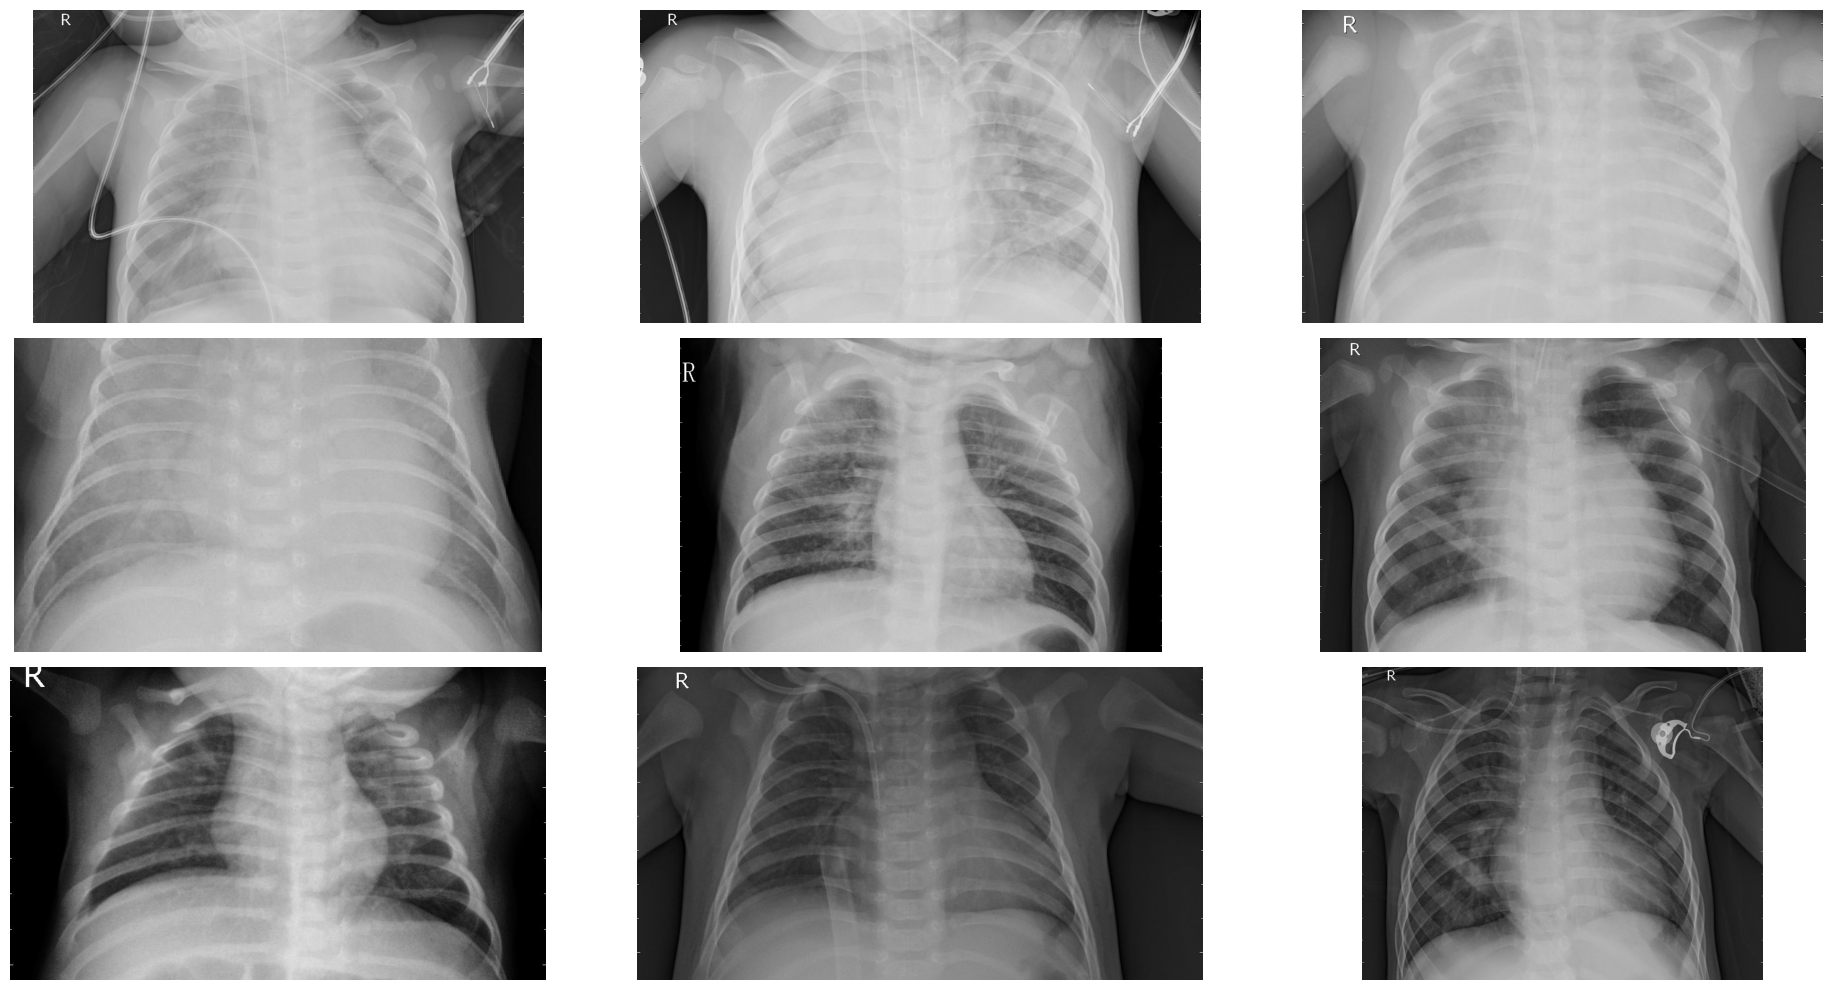

In [14]:
pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
pneumonia = os.listdir(pneumonia_dir)

plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(pneumonia_dir, pneumonia[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

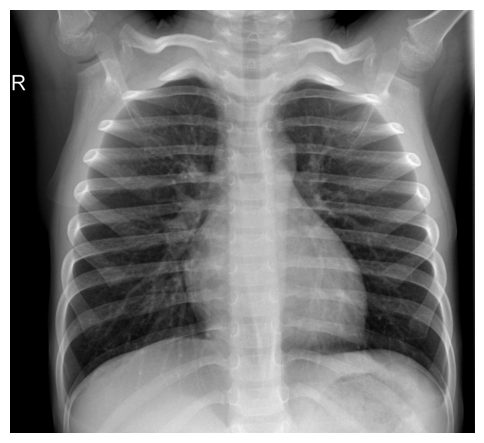

In [15]:
normal_dir = os.path.join(train_dir, "NORMAL")
normal_sample = os.listdir(normal_dir)[0]

img = plt.imread(os.path.join(normal_dir, normal_sample))
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [16]:
image_generator = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    samplewise_center=True,
    samplewise_std_normalization=True
)

val_test_generator = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True
)

train = image_generator.flow_from_directory(
    train_dir, batch_size=48, shuffle=True, class_mode='binary', target_size=(180, 180)
)
validation = val_test_generator.flow_from_directory(
    val_dir, batch_size=48, shuffle=False, class_mode='binary', target_size=(180, 180)
)
test = val_test_generator.flow_from_directory(
    test_dir, batch_size=1, shuffle=False, class_mode='binary', target_size=(180, 180)
)

Found 5884 images belonging to 2 classes.
Found 1265 images belonging to 2 classes.
Found 1272 images belonging to 2 classes.


This is the preprocessing step. It includes resizing every image to 180x180 pixels and normalizing pixel values so the CNN receives consistent input. For the training set specifically, it also applies random augmentation (rotation, shift, zoom, shear) to every image on every epoch, so the model sees slightly different versions each time and is less likely to memorize the images. We can also notice that batch_size differs between train (8) and val/test (1). For training, batch_size determines how many images are processed before weights are updated. For val/test, no weight updates happen at all — the model is only making predictions — so batch_size=1 is just a simple choice.

In [17]:
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))

weight_for_0 = num_pneumonia / (num_normal + num_pneumonia)
weight_for_1 = num_normal / (num_normal + num_pneumonia)

class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for class 0: {weight_for_0:.2f}")
print(f"Weight for class 1: {weight_for_1:.2f}")

Weight for class 0: 0.66
Weight for class 1: 0.34


Because Pneumonia has significantly more images than Normal in our training data, we add the code above to counter any class imbalance the model might learn. We essentially punish the model more for wrong predictions on the Normal class (the minority) by giving it a higher weight in the cross entropy loss calculation.

In [23]:
tf.keras.backend.clear_session()

model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=(180,180,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 178, 178, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 85, 85, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 85, 85, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,685,185 (25.50 MB)

 Trainable params: 6,684,609 (25.50 MB)

 Non-trainable params: 576 (2.25 KB)

The model summary shows the full CNN architecture layer by layer. The image starts at 180x180 and progressively shrinks through 3 MaxPooling layers (178→88→42→19) while the number of filters grows (32→64→128) — detecting increasingly complex patterns at each stage while keeping only the strongest signals. After the final pooling layer, the 19x19x128 output gets flattened into 46,208 numbers, which feed into a Dense hidden layer of 128 neurons (the familiar multiply-by-weights + bias + ReLU process). Notice the Dense layer alone has 5,914,752 parameters — the majority of the model's 6.2 million total trainable parameters — because every one of the 46,208 flattened values connects to every one of the 128 neurons. A Dropout layer randomly disables 20% of neurons during training to prevent over-reliance on any single neuron. Finally, the output layer (dense_1) has a single neuron with sigmoid activation, outputting a probability between 0 and 1 — close to 0 means Normal, close to 1 means Pneumonia.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

start = time.time()
r = model.fit(
    train, epochs=30, validation_data=validation,
    class_weight=class_weight, callbacks=[early_stop, reduce_lr]
)
cnn_train_time = time.time() - start
print(f"CNN training time: {cnn_train_time:.2f}s")

In [45]:
evaluation = model.evaluate(test)
print(f"Test Accuracy: {evaluation[1] * 100:.2f}%")


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9119 - loss: 0.2314
Test Accuracy: 91.19%


In [46]:
test.reset()
pred_probs = model.predict(test, steps=len(test), verbose=1)
pred_classes = (pred_probs > 0.5).astype(int).flatten()

print(f"True labels: {len(test.classes)}, Predictions: {len(pred_classes)}")

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step
True labels: 1272, Predictions: 1272


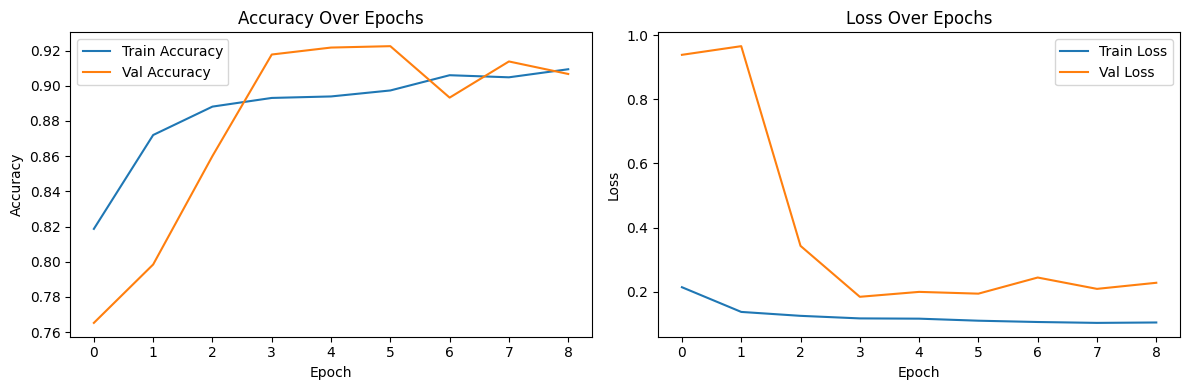

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(r.history['accuracy'], label='Train Accuracy')
plt.plot(r.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(r.history['loss'], label='Train Loss')
plt.plot(r.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Reset test generator
test = test_generator.flow_from_directory(
    test_dir,
    batch_size=1,
    shuffle=False,
    class_mode='binary',
    target_size=(180, 180)
)

# Get predictions
pred = model.predict(test, steps=624)
pred_classes = (pred > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(test.classes, pred_classes)
print(cm)
print(classification_report(test.classes, pred_classes, target_names=['Normal', 'Pneumonia']))

Dataset: Chest X-ray Pneumonia (5,216 train, 624 test)
Architecture: CNN - 3 Conv blocks, BatchNorm, MaxPool, Dense(128), Dropout(0.5)
Key finding: Reduced architecture complexity + increased dropout improved 
             baseline accuracy from 84.62% to 85.42%
Limitation: Small validation set (16 images) made tuning unreliable
Limitation: Class imbalance affects Normal detection despite class weighting

In [57]:
classical_generator = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True
)

train_gen = classical_generator.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=5884,
    class_mode='binary',
    shuffle=False
)

test_gen = classical_generator.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=1273,
    class_mode='binary',
    shuffle=False
)

X_train, y_train = next(train_gen)
X_test, y_test = next(test_gen)

X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(f"Training data shape: {X_train_flat.shape}")
print(f"Test data shape: {X_test_flat.shape}")

Found 5884 images belonging to 2 classes.
Found 1272 images belonging to 2 classes.
Training data shape: (5884, 12288)
Test data shape: (1272, 12288)


In [58]:
X_train_flat = X_train_flat.astype('float32')
X_test_flat = X_test_flat.astype('float32')

In [59]:
# ── PCA with 450 components — used by SVM and Logistic Regression ──
from sklearn.decomposition import PCA

pca_450 = PCA(n_components=450, random_state=42)
X_train_pca_450 = pca_450.fit_transform(X_train_flat)
X_test_pca_450 = pca_450.transform(X_test_flat)

print(f"Training data shape: {X_train_pca_450.shape}")
print(f"Test data shape: {X_test_pca_450.shape}")
print(f"Explained variance retained: {pca_450.explained_variance_ratio_.sum()*100:.2f}%")

Training data shape: (5884, 450)
Test data shape: (1272, 450)
Explained variance retained: 93.47%


In [60]:
# ── PCA with 150 components — used by KNN and Random Forest baseline ──
from sklearn.decomposition import PCA

pca = PCA(n_components=150, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print(f"Training data shape: {X_train_pca.shape}")
print(f"Test data shape: {X_test_pca.shape}")
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Training data shape: (5884, 150)
Test data shape: (1272, 150)
Explained variance retained: 86.78%


In [61]:
# ── Logistic Regression ──
start = time.time()
lr_model = LogisticRegression(max_iter=3000, C=0.1, solver='saga', class_weight='balanced')
lr_model.fit(X_train_pca_450, y_train)
lr_time = time.time() - start
lr_pred = lr_model.predict(X_test_pca_450)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression → Accuracy: {lr_acc*100:.2f}% | Time: {lr_time:.2f}s")

Logistic Regression → Accuracy: 88.92% | Time: 168.10s


In [62]:
# ── SVM ──
start = time.time()
svm_model = SVC(kernel='rbf', C=10)
svm_model.fit(X_train_pca_450, y_train)
svm_time = time.time() - start
svm_pred = svm_model.predict(X_test_pca_450)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM → Accuracy: {svm_acc*100:.2f}% | Time: {svm_time:.2f}s")

SVM → Accuracy: 90.41% | Time: 2.90s


In [63]:
# ── Random Forest ──
start = time.time()
rf_model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
rf_model.fit(X_train_flat, y_train)
rf_time = time.time() - start
rf_pred = rf_model.predict(X_test_flat)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest → Accuracy: {rf_acc*100:.2f}% | Time: {rf_time:.2f}s")

Random Forest → Accuracy: 88.21% | Time: 263.24s


In [64]:
# ── KNN ──
start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='euclidean')
knn_model.fit(X_train_flat, y_train)
knn_time = time.time() - start
knn_pred = knn_model.predict(X_test_flat)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN → Accuracy: {knn_acc*100:.2f}% | Time: {knn_time:.2f}s")

KNN → Accuracy: 88.92% | Time: 0.04s


In [65]:
print(X_train_flat.shape)   # expect ~(5885, 12288)
print(X_test_flat.shape)    # expect ~(1273, 12288)
print(len(y_train))         # expect ~5885
print(len(y_test)) 

(5884, 12288)
(1272, 12288)
5884
1272


In [66]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D

tf.keras.backend.clear_session()

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(180,180,3))
base_model.trainable = False

densenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

densenet_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [76]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

start = time.time()
r_dense = densenet_model.fit(
    train, epochs=30, validation_data=validation,
    class_weight=class_weight, callbacks=[early_stop, reduce_lr]
)
densenet_train_time = time.time() - start
print(f"DenseNet training time: {densenet_train_time:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [68]:
start = time.time()
evaluation_dense = densenet_model.evaluate(test)
densenet_eval_time = time.time() - start
print(f"DenseNet Test Accuracy: {evaluation_dense[1] * 100:.2f}%")

start = time.time()
densenet_model.predict(test)
densenet_pred_time = time.time() - start

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9064 - loss: 0.2566
DenseNet Test Accuracy: 90.64%
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step


In [77]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

tf.keras.backend.clear_session()

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(180,180,3))
resnet_base.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

resnet_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [78]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

start = time.time()
r_resnet = resnet_model.fit(
    train, epochs=30, validation_data=validation,
    class_weight=class_weight, callbacks=[early_stop, reduce_lr]
)
resnet_train_time = time.time() - start

Epoch 1/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 126s 946ms/step - accuracy: 0.6236 - loss: 0.2954 - val_accuracy: 0.8332 - val_loss: 0.5131 - learning_rate: 1.0000e-04
Epoch 2/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 108s 875ms/step - accuracy: 0.7578 - loss: 0.2365 - val_accuracy: 0.8206 - val_loss: 0.4766 - learning_rate: 1.0000e-04
Epoch 3/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 109s 889ms/step - accuracy: 0.7915 - loss: 0.2146 - val_accuracy: 0.8561 - val_loss: 0.4134 - learning_rate: 1.0000e-04
Epoch 4/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 108s 880ms/step - accuracy: 0.8137 - loss: 0.1961 - val_accuracy: 0.8601 - val_loss: 0.3781 - learning_rate: 1.0000e-04
Epoch 5/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 108s 878ms/step - accuracy: 0.8268 - loss: 0.1899 - val_accuracy: 0.8640 - val_loss: 0.3700 - learning_rate: 1.0000e-04
Epoch 6/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 109s 884ms/step - accuracy: 0.8382 - loss: 0.1787 - val_accuracy: 0.8672 - val_loss: 0.3648 - learning_rate: 1.0000e-04
Epoch 7/30
123/123 ━━━━━━━━━━━━━━━━━━━━ 

In [79]:
start = time.time()
evaluation_resnet = resnet_model.evaluate(test)
resnet_eval_time = time.time() - start
print(f"ResNet-50 Test Accuracy: {evaluation_resnet[1] * 100:.2f}%")

start = time.time()
resnet_model.predict(test)
resnet_pred_time = time.time() - start

1272/1272 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8742 - loss: 0.3115
ResNet-50 Test Accuracy: 87.42%
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step


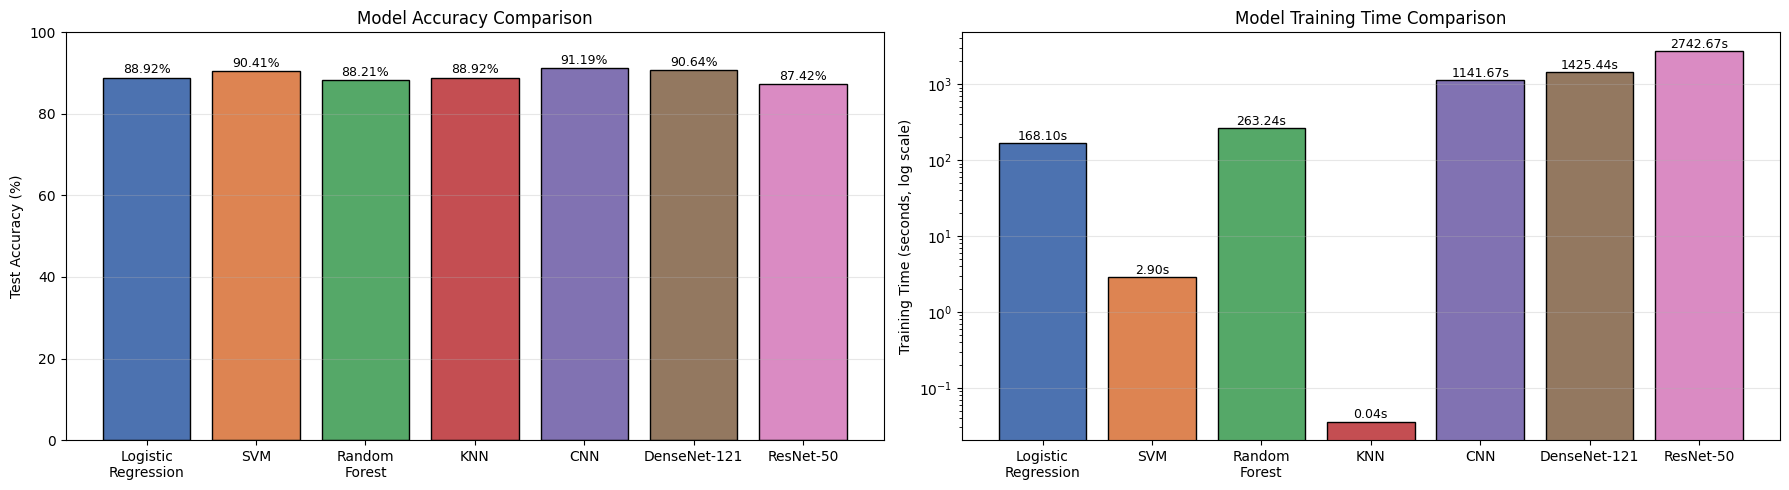

In [80]:
# ── Accuracy and Time — bar charts ──
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic\nRegression', 'SVM', 'Random\nForest', 'KNN', 'CNN', 'DenseNet-121', 'ResNet-50']
accuracies = [lr_acc*100, svm_acc*100, rf_acc*100, knn_acc*100, evaluation[1]*100, evaluation_dense[1]*100, evaluation_resnet[1]*100]
times = [lr_time, svm_time, rf_time, knn_time, cnn_train_time, densenet_train_time, resnet_train_time]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

bars1 = axes[0].bar(models, accuracies, color=colors, edgecolor='black')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0, 100)
axes[0].grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.2f}%', ha='center', fontsize=9)

bars2 = axes[1].bar(models, times, color=colors, edgecolor='black')
axes[1].set_ylabel('Training Time (seconds, log scale)')
axes[1].set_title('Model Training Time Comparison')
axes[1].set_yscale('log')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1, f'{t:.2f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [81]:
print(type(model))
print(model)

<class 'keras.src.models.sequential.Sequential'>
<Sequential name=sequential, built=True>


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step


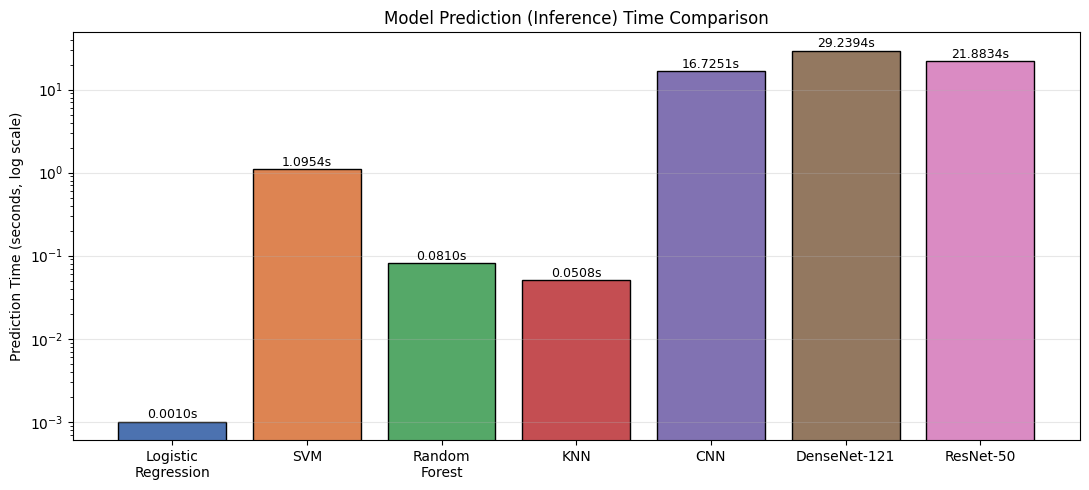

In [82]:
# ── Prediction/Testing Time Comparison ──
import time

# Retrain each model fresh right here to guarantee correct data pairing
lr_model = LogisticRegression(max_iter=3000, C=0.1, solver='saga', class_weight='balanced')
lr_model.fit(X_train_pca_450, y_train)

svm_model = SVC(kernel='rbf', C=10)
svm_model.fit(X_train_pca_450, y_train)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
rf_model.fit(X_train_flat, y_train)

knn_model = KNeighborsClassifier(n_neighbors=15, weights='uniform', metric='euclidean')
knn_model.fit(X_train_pca, y_train)

# Now time predictions
start = time.time(); lr_model.predict(X_test_pca_450); lr_pred_time = time.time() - start
start = time.time(); svm_model.predict(X_test_pca_450); svm_pred_time = time.time() - start
start = time.time(); rf_model.predict(X_test_flat); rf_pred_time = time.time() - start
start = time.time(); knn_model.predict(X_test_pca); knn_pred_time = time.time() - start
start = time.time(); model.predict(test); cnn_pred_time = time.time() - start

pred_times = [lr_pred_time, svm_pred_time, rf_pred_time, knn_pred_time, cnn_pred_time, densenet_pred_time, resnet_pred_time]

plt.figure(figsize=(11,5))
bars = plt.bar(models, pred_times, color=colors, edgecolor='black')
plt.ylabel('Prediction Time (seconds, log scale)')
plt.yscale('log')
plt.title('Model Prediction (Inference) Time Comparison')
plt.grid(True, axis='y', alpha=0.3)
for bar, t in zip(bars, pred_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1, f'{t:.4f}s', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

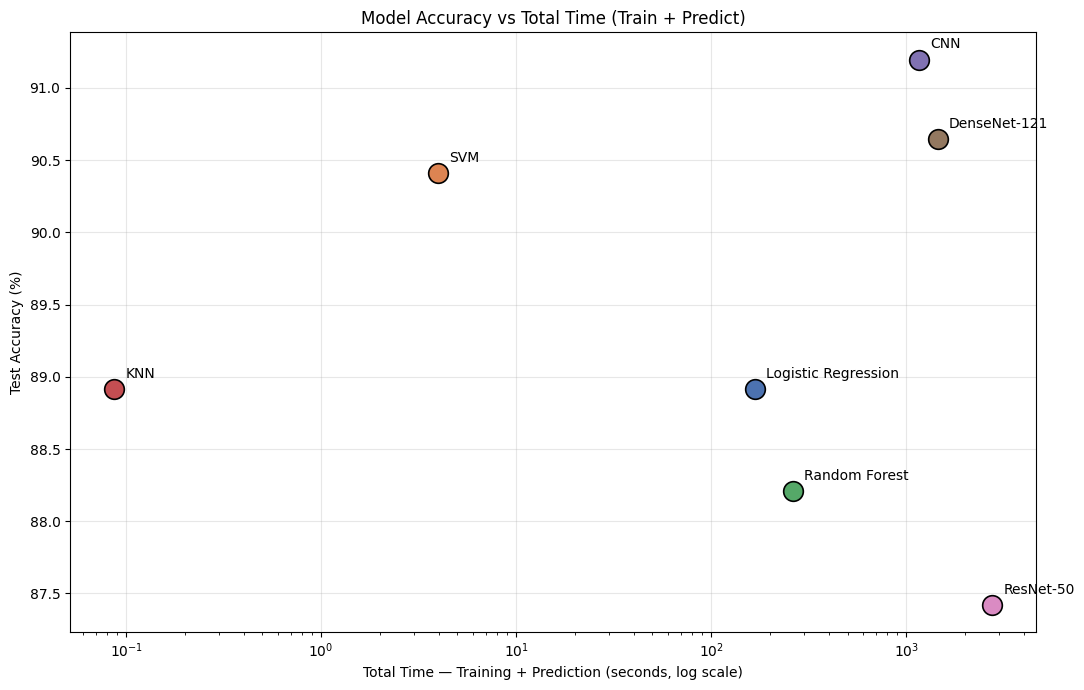

In [83]:
# ── Accuracy vs Total Time (Train + Predict) — scatter comparison ──
total_times = [
    lr_time + lr_pred_time,
    svm_time + svm_pred_time,
    rf_time + rf_pred_time,
    knn_time + knn_pred_time,
    cnn_train_time + cnn_pred_time,
    densenet_train_time + densenet_pred_time,
    resnet_train_time + resnet_pred_time
]

plt.figure(figsize=(11, 7))
for i, model_name in enumerate(models):
    plt.scatter(total_times[i], accuracies[i], s=200, color=colors[i], label=model_name, edgecolors='black', linewidth=1.2)
    plt.annotate(model_name.replace('\n', ' '), (total_times[i], accuracies[i]), textcoords="offset points", xytext=(8, 8), fontsize=10)

plt.xscale('log')
plt.xlabel('Total Time — Training + Prediction (seconds, log scale)')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Accuracy vs Total Time (Train + Predict)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()